In [1]:
import os
import sys
import json

import mass_ts as mts

c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\.venv\Lib\site-packages\mass_ts\_mass_ts.py:17: UserWarning: GPU support will not work. You must pip install mass-ts[gpu].
  warnings.warn(


In [2]:
dir_base = "../../"
print(os.path.abspath(dir_base))

sys.path.append(os.path.abspath(dir_base))

c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg


In [3]:
from backend.ml.data_utils.load_data import load_metadata
from backend.ml.data_utils.prepare_data import split_participants_min_per_class
from backend.ml.train import train_save_model
from backend.ml.model_vars import PRETRAINED_MODEL_DIR

In [4]:
dir_data = os.path.join(dir_base, "data", "datasets", "ds004504")

# probably add timestamp to the model name to keep track of different runs
df_metadata_orig = load_metadata(dir_data=dir_data)

participants_splits_path = os.path.join(dir_base, "backend\ml\data_splits.json")

# load json file participants splits
with open(participants_splits_path, "r") as f:
    participants_splits = json.load(f)


i = 0
participants_ids_train = participants_splits[str(i)]["train"]
participants_ids_val = participants_splits[str(i)]["val"]
participants_ids_test = participants_splits[str(i)]["test"]

df_metadata = df_metadata_orig.copy(deep=True)

df_metadata.loc[df_metadata["participant_id_int"].isin(participants_ids_train), "datasplit"] = "train"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_ids_val), "datasplit"] = "val"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_ids_test), "datasplit"] = "test"

<>:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\grabn\AppData\Local\Temp\ipykernel_12768\2339135799.py:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  participants_splits_path = os.path.join(dir_base, "backend\ml\data_splits.json")


In [5]:
## load model and metadata
import torch
from backend.ml.data_utils.load_data import *
from backend.ml.data_utils.prepare_data import *


In [6]:
n_participants = df_metadata["participant_id_int"].max()
participants_ids = list(range(1, n_participants + 1))

df_eeg = load_multiple_eegfiles(
    dir_data=dir_data,
    participant_ids=participants_ids,  # , 43
    gen_path_func=gen_filename,
    df_metadata=df_metadata,
    # n_max=1000,
    n_max=10000,
)

Total memory usage of combined df_eeg: 73.85 MB


In [7]:
train_ids = [f"sub-{str(id).zfill(3)}" for id in participants_ids_train]
val_ids = [f"sub-{str(id).zfill(3)}" for id in participants_ids_val]
test_ids = [f"sub-{str(id).zfill(3)}" for id in participants_ids_test]

df_train = df_eeg[df_eeg["participant_id"].isin(train_ids)]
df_val = df_eeg[df_eeg["participant_id"].isin(val_ids)]
df_test = df_eeg[df_eeg["participant_id"].isin(test_ids)]

In [8]:
df_val.head(2)

,time,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,...,F8,T3,T4,T5,T6,Fz,Cz,Pz,participant_id,diagnosis
10000,0.000,146.695602,19.276262,7.566239,11.171651,-39.752701,-37.825321,80.982742,-55.761948,-7.745028,...,-40.541298,-11.798263,40.656189,-0.427597,-47.409206,-19.362051,-23.177048,-4.642809,sub-002,1
10001,0.008,175.211777,48.746956,36.096474,53.065418,-1.176135,-7.169729,109.950645,-20.503822,29.181461,...,-0.712968,20.184607,69.794380,37.489178,-5.716342,15.455943,8.719716,28.478216,sub-002,1


In [9]:
import numpy as np
import pandas as pd
import mass_ts as mts
from tqdm import tqdm

def matrix_profile_vs_classes(
    df_test: pd.DataFrame,
    df_train: pd.DataFrame,
    channel: str,
    window_size: int,
    step: int = None,
):
    """
    For each test recording, slide a window across it and compute the minimum
    """
    diagnosis_values = [0, 1, 2]  # assuming these are the possible diagnosis values
    x_train = {}
    for diag in diagnosis_values:
        x_train[diag] = df_train[df_train["diagnosis"] == diag][channel].values

    x_test = x_test = df_test[channel].values
    y_test = df_test["diagnosis"].values

    df_results = matrix_profile_vs_classes_inner(
        test_signal=x_test,
        train_signals=x_train,
        window_size=window_size,
        step=step,
        true_label=y_test,
    )
    return df_results
   

def matrix_profile_vs_classes_inner(
    test_signal: np.ndarray,
    train_signals: dict,            # e.g. {0: x_train_0, 1: x_train_1, 2: x_train_2}
    window_size: int,
    step: int = None,
    true_label: np.ndarray = None,
):
    """
    Slide a window across `test_signal` and, for each position, compute the
    minimum MASS distance to each training class signal.

    Parameters
    ----------
    test_signal : 1D array
        The test recording to profile.
    train_signals : dict[label -> 1D array]
        One long training signal per class.
    window_size : int
        Length of the query subsequence (in samples).
    step : int
        Stride between consecutive query starts. step=1 is the textbook
        matrix profile; larger steps are much faster and usually fine for EEG.

    Returns
    -------
    pd.DataFrame with columns:
        start_idx, min_dist_<label> for each label, predicted_class
    """
    labels = sorted(train_signals.keys())
    n = len(test_signal)
    if step is None:
        step = window_size
    starts = range(0, n - window_size + 1, step)

    rows = []
    # print which class is currently done
    for s in tqdm(starts):
        query = test_signal[s : s + window_size]
        row = {"start_idx": s}

        if true_label is not None:
            true_labels = true_label[s : s + window_size]
            if len(set(true_labels)) == 1:
                row["true_label"] = true_labels[0]
            else:
                print(f"Warning: window starting at {s} contains multiple true labels: {set(true_labels)}")
                continue  # skip this window

        for lbl in labels:
            ts = train_signals[lbl]
            if len(ts) < window_size:
                row[f"min_dist_{lbl}"] = np.nan
                continue
            d = np.abs(mts.mass2(ts, query))
            row[f"min_dist_{lbl}"] = float(d.min())
        rows.append(row)

    df = pd.DataFrame(rows)
    dist_cols = [f"min_dist_{lbl}" for lbl in labels]
    df["predicted_class"] = df[dist_cols].idxmin(axis=1).str.replace("min_dist_", "").astype(int)

    if "true_label" not in df.columns:
        df["true_label"] = np.nan

    # reorder columns, put true label next to predicted
    cols = ["start_idx"] + dist_cols + ["true_label", "predicted_class"]
    df = df[cols]


    # df["true_label"] = df["true_label"].fillna(method="ffill")
    return df

In [10]:
channel = "O1"
diagnosis_values = [0, 1, 2]

In [11]:
df_test.head()

,time,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,...,F8,T3,T4,T5,T6,Fz,Cz,Pz,participant_id,diagnosis
70000,0.000,75.596336,-115.822662,172.206299,252.307373,144.150909,15.343811,359.849304,46.804356,-95.509811,...,262.060272,347.018524,46.145992,134.871780,328.966980,255.964539,319.444580,163.095993,sub-008,1
70001,0.008,-16.573286,-196.336777,98.681755,195.422699,55.208035,-73.772102,270.642914,-37.545235,-180.595795,...,179.034073,258.088501,-32.691280,50.353142,245.230179,174.247116,231.193024,77.067924,sub-008,1
70002,0.016,51.336071,-119.279564,164.900940,250.742767,116.836792,-9.994209,333.051025,24.988834,-116.769096,...,248.251511,320.328278,31.852474,114.160355,311.391296,241.392258,292.110687,138.770920,sub-008,1
70003,0.024,8.805309,-173.959518,116.221626,213.878723,71.408699,-51.559353,294.409851,-13.228622,-153.020157,...,203.864288,280.317017,-12.706314,73.478813,273.875610,197.029816,250.644104,101.236343,sub-008,1
70004,0.032,47.448055,-141.381638,156.961151,253.645309,117.294731,-6.413609,336.499634,32.223492,-117.396751,...,236.114914,324.064606,33.305153,113.932388,312.826050,237.703278,299.109497,145.984497,sub-008,1


In [12]:
x_train = {}
x_val = {}
x_test = {}

for diag in diagnosis_values:
    x_train[diag] = df_train[df_train["diagnosis"] == diag][channel].values
    x_val[diag] = df_val[df_val["diagnosis"] == diag][channel].values
    x_test[diag] = df_test[df_test["diagnosis"] == diag][channel].values

In [13]:
# x_train_0 = df_train[df_train["diagnosis"] == 0][channel].values
# x_train_1 = df_train[df_train["diagnosis"] == 1][channel].values
# x_train_2 = df_train[df_train["diagnosis"] == 2][channel].values

# x_val_0 = df_val[df_val["diagnosis"] == 0][channel].values
# x_val_1 = df_val[df_val["diagnosis"] == 1][channel].values
# x_val_2 = df_val[df_val["diagnosis"] == 2][channel].values

# x_test_0 = df_test[df_test["diagnosis"] == 0][channel].values
# x_test_1 = df_test[df_test["diagnosis"] == 1][channel].values
# x_test_2 = df_test[df_test["diagnosis"] == 2][channel].values

In [14]:
downsample = True

nb_classes = 3
Chans = 19
srate = 125 if downsample else 250
workers = 0
batchsize = 64

window = 4
sample_length = int(srate * window)

In [15]:
window_size = window * srate

In [16]:
x_train

{0: array([-42.124123, -28.644802, -50.082466, ...,  18.677797,  18.938179,
         12.789422], shape=(170000,), dtype=float32),
 1: array([149.88326 , 149.04256 , 149.26283 , ...,  23.872065,  40.119045,
         38.20146 ], shape=(240000,), dtype=float32),
 2: array([-45.948555,   6.75277 , -61.997578, ..., 305.86118 , 302.66617 ,
        302.8925  ], shape=(140000,), dtype=float32)}

In [17]:
query = x_test[0][:window_size]
print(query.shape)
print(x_train[0].shape)

distances = np.abs(mts.mass2(x_train[0], query))
min_k = np.argmin(distances)
min_distance = distances[min_k]
print(f"Minimum distance: {min_distance} class 0")

distances = np.abs(mts.mass2(x_train[1], query))
min_k = np.argmin(distances)
min_distance = distances[min_k]
print(f"Minimum distance: {min_distance} class 1")

distances = np.abs(mts.mass2(x_train[2], query))
min_k = np.argmin(distances)
min_distance = distances[min_k]
print(f"Minimum distance: {min_distance} class 2")

(500,)
(170000,)
Minimum distance: 12.40363956965798 class 0
Minimum distance: 13.400491289476264 class 1
Minimum distance: 13.424249668211456 class 2


In [18]:
# df_profile_test0 = matrix_profile_vs_classes_inner(
#     test_signal=x_test[0],
#     train_signals=x_train,
#     window_size=window_size,
#     step=window_size,   # non-overlapping windows; try smaller for finer resolution
# )

# # quick sanity check: how often does each predicted class win?
# print(df_profile_test0["predicted_class"].value_counts())
# df_profile_test0

In [19]:
channel

'O1'

In [ ]:
df_result = matrix_profile_vs_classes(
    df_test=df_test,
    df_train=df_train,
    channel=channel,
    window_size=window_size,  # 1 second at 256Hz; adjust as needed
    step=window_size,   # non-overlapping windows; try smaller for finer resolution
)   


accuracy = (df_result["true_label"] == df_result["predicted_class"]).mean()
print(f"Overall accuracy: {accuracy:.4f}")

# recall, precision and f1-score per class

recall_dict = {}
precision_dict = {}
f1_score_dict = {}

for diag in diagnosis_values:
    class_mask = df_result["true_label"] == diag
    if class_mask.sum() > 0:
        recall = (df_result.loc[class_mask, "predicted_class"] == diag).mean()

        precision = (df_result.loc[class_mask, "predicted_class"] == diag).mean()
        if recall + precision > 0:
            f1_score = 2 * (recall * precision) / (recall + precision)
        else:
            f1_score = 0

        recall_dict[diag] = recall
        precision_dict[diag] = precision
        f1_score_dict[diag] = f1_score

    print(f"Class {diag}: Recall = {recall_dict[diag]:.4f}, Precision = {precision_dict[diag]:.4f}, F1-Score = {f1_score_dict[diag]:.4f}")

df_result

 78%|███████▊  | 282/360 [03:38<01:03,  1.22it/s]

In [ ]:
def z_norm(signal):
    mean = np.mean(signal)
    std = np.std(signal)
    if std == 0:
        return signal - mean  # avoid division by zero
    return (signal - mean) / std

In [ ]:
x_test

{0: array([ 40.994724,  63.66651 ,  53.131786, ..., 128.5078  , 121.12929 ,
        148.01529 ], shape=(60000,), dtype=float32),
 1: array([ -95.50981, -180.5958 , -116.7691 , ...,  107.10222,  116.07719,
         110.09158], shape=(60000,), dtype=float32),
 2: array([ -8.502948 , -36.200615 ,   0.7000127, ..., 617.22125  ,
        605.2551   , 609.5883   ], shape=(60000,), dtype=float32)}

In [ ]:
class_map = {0: "Healthy", 1: "AD", 2: "FTD"}

In [ ]:
dir_base = "../../"
os.path.abspath(dir_base)

'c:\\Users\\grabn\\Documents\\CGV_2024\\xeegVis_alll\\all-in-on-eeg'

(500,)
(170000,)
True label: AD (1)
Minimum distance: 11.296313489563794 class 0
Minimum distance: 12.630461401617424 class 1
Minimum distance: 13.955203312905912 class 2
Match: (500,)


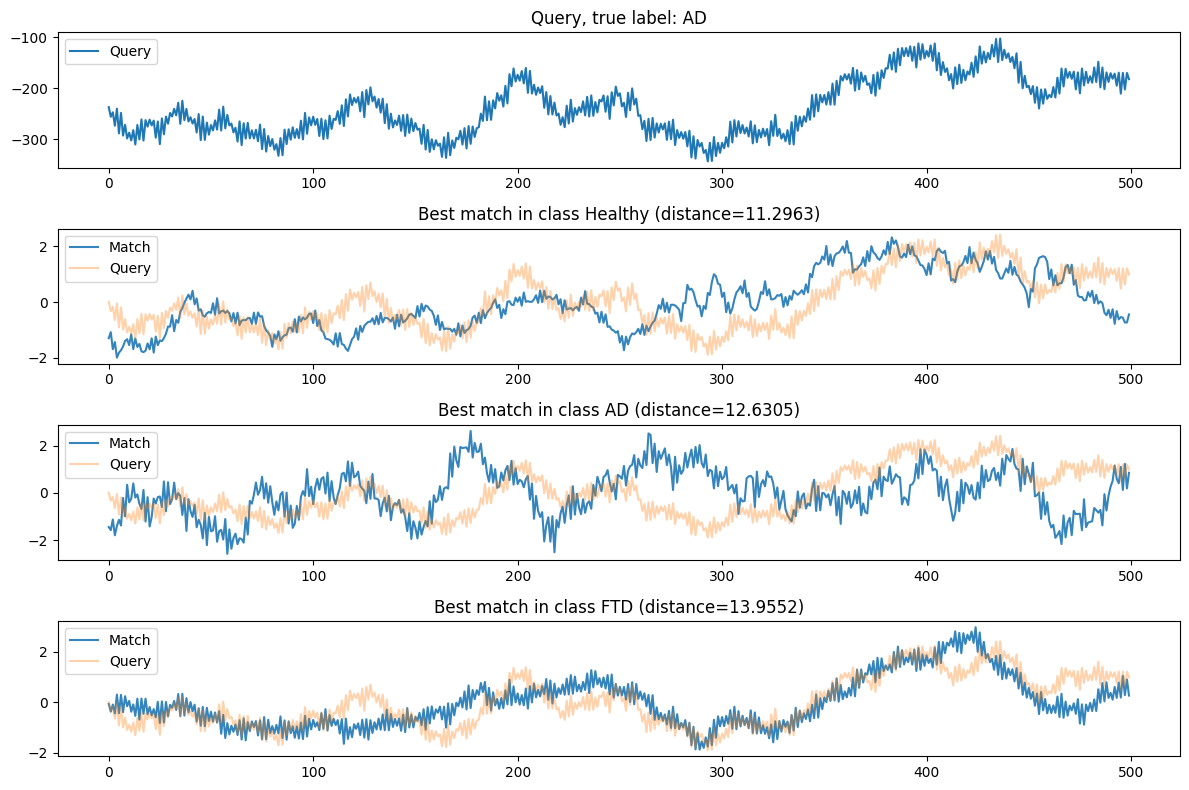

In [ ]:
save_fig = False

# start_idx = 177500
start_idx = 2000
# true_label = 0

query = df_test.reset_index(drop=True).loc[start_idx : start_idx + window_size-1, channel].values
true_labels = df_test.reset_index(drop=True).loc[start_idx : start_idx + window_size, "diagnosis"].unique()
if len(set(true_labels)) == 1:
    true_label = true_labels[0]
else:
    print(f"Warning: window starting at {start_idx} contains multiple true labels: {set(true_labels)}")

min_distances = {}

# query = x_test[0][:window_size]
print(query.shape)
print(x_train[0].shape)

print(f"True label: {class_map[true_label]} ({true_label})")

distances = np.abs(mts.mass2(x_train[0], query))
min_k = np.argmin(distances)
min_distance = distances[min_k]
min_distances[0] = min_distance

match = x_train[0][min_k : min_k + window_size]
print(f"Minimum distance: {min_distance} class 0")

distances = np.abs(mts.mass2(x_train[1], query))
min_k = np.argmin(distances)
min_distance = distances[min_k]
min_distances[1] = min_distance
match = x_train[1][min_k : min_k + window_size]
print(f"Minimum distance: {min_distance} class 1")

distances = np.abs(mts.mass2(x_train[2], query))
min_k = np.argmin(distances)
min_distance = distances[min_k]
min_distances[2] = min_distance
match = x_train[2][min_k : min_k + window_size]
print(f"Minimum distance: {min_distance} class 2")

print(f"Match: {match.shape}")

# plot query and matches
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.plot(query, label="Query")
plt.legend()
plt.title(f"Query, true label: {class_map[true_label]}")
# plt.title("Query")
for i, diag in enumerate(diagnosis_values):
    plt.subplot(4, 1, i + 2)
    match = x_train[diag][min_k : min_k + window_size]
    # plt.plot(match)
    # plt.plot(query, alpha=0.3)
    plt.plot(z_norm(match), alpha=0.9, label="Match")
    plt.plot(z_norm(query), alpha=0.35, label="Query")
    plt.title(f"Best match in class {class_map[diag]} (distance={min_distances[diag]:.4f})")
    plt.legend()
plt.tight_layout()

## save figure
if save_fig:
    dir_figure = os.path.join(dir_base, "figures")
    fig_name = f"matrix_profile_example_start_idx{start_idx}.pdf"
    plt.savefig(os.path.join(dir_figure, fig_name))


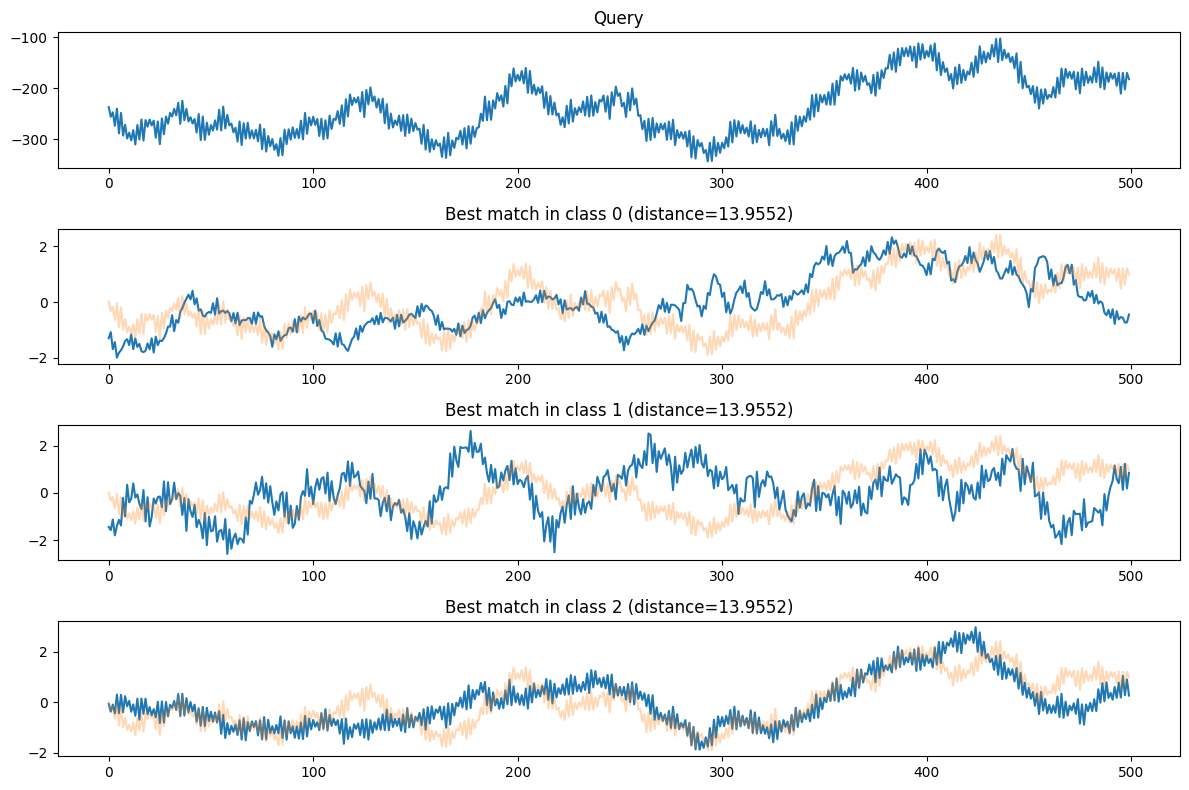

In [90]:

# plot query and matches
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.plot(query)
plt.title("Query")
for i, diag in enumerate(diagnosis_values):
    plt.subplot(4, 1, i + 2)
    match = x_train[diag][min_k : min_k + window_size]
    plt.plot(z_norm(match))
    plt.plot(z_norm(query), alpha=0.3)
    plt.title(f"Best match in class {diag} (distance={min_distance:.4f})")
plt.tight_layout()


In [130]:
x_columns = [
    "time",
    "Fp1",
    "Fp2",
    "F3",
    "F4",
    "C3",
    "C4",
    "P3",
    "P4",
    "O1",
    "O2",
    "F7",
    "F8",
    "T3",
    "T4",
    "T5",
    "T6",
    "Fz",
    "Cz",
    "Pz",
]


In [131]:
x_train, y_train = reshape_eeg_multipl(
    df_train, x_columns=x_columns, y_column="diagnosis", Chans=Chans, sample_length=sample_length
)
x_val, y_val = reshape_eeg_multipl(
    df_val, x_columns=x_columns, y_column="diagnosis", Chans=Chans, sample_length=sample_length
)
x_test, y_test = reshape_eeg_multipl(
    df_test, x_columns=x_columns, y_column="diagnosis", Chans=Chans, sample_length=sample_length
)

# trainloader = DataLoader(list(zip(x_train, y_train)), batch_size=batchsize, shuffle=True, num_workers=workers)
# valloader = DataLoader(list(zip(x_val, y_val)), batch_size=batchsize, shuffle=False, num_workers=workers)
# testloader = DataLoader(list(zip(x_test, y_test)), batch_size=batchsize, shuffle=False, num_workers=workers)

100%|██████████| 18/18 [00:00<00:00, 86.86it/s]


In [132]:
print(y_train)

tensor([1, 1, 1,  ..., 2, 2, 2])


In [133]:
print(sum(y_train == 0))
print(sum(y_train == 1))
print(sum(y_train == 2))
###
# print reltive distribution of classes in train, val, test
print(sum(y_train == 0) / len(y_train))
print(sum(y_train == 1) / len(y_train))
print(sum(y_train == 2) / len(y_train))


tensor(340)
tensor(480)
tensor(280)
tensor(0.3091)
tensor(0.4364)
tensor(0.2545)


In [134]:
print(sum(y_test == 0))
print(sum(y_test == 1))
print(sum(y_test == 2))

tensor(120)
tensor(120)
tensor(120)
